<a href="https://colab.research.google.com/github/achbogga/helio/blob/dev_achbogga/Pytorch_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Insatlling Pyorch

!pip install torch
!pip install torchvision

In [2]:
#@title Import Dependencies

import torch
import torch.nn as nn
import torchvision.datasets as dsets
import torchvision.transforms as transforms
from torch.autograd import Variable

In [3]:
#@title Define Hyperparameters

input_size = 784 # img_size = (28,28) ---> 28*28=784 in total
hidden_size = 500 # number of nodes at hidden layer
num_classes = 10 # number of output classes discrete range [0,9]
num_epochs = 20 # number of times which the entire dataset is passed throughout the model
batch_size = 100 # the size of input data took for one iteration
lr = 1e-3 # size of step

In [4]:
#@title Downloading MNIST data

import torch
from torchvision.datasets import MNIST

# 1. Download/load MNIST (no transforms needed)
train_data = MNIST(root='./data', train=True, download=True)
test_data = MNIST(root='./data', train=False, download=True)

# 2. Convert to float and scale [0,1]
data = train_data.data.float() / 255.0       # shape: (60000, 28, 28)

# 3. Compute per-channel mean & std
MNIST_MEAN = data.mean().item()                    # scalar
MNIST_STD  = data.std().item()                     # scalar

print(f'MNIST mean = {MNIST_MEAN:.4f},  std = {MNIST_STD:.4f}')


MNIST mean = 0.1307,  std = 0.3081


In [5]:
#@title Define Transforms

# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Apply transforms to the datasets
train_data.transform = transform
test_data.transform = transform

In [6]:
#@title Loading the data

train_gen = torch.utils.data.DataLoader(dataset = train_data,
                                             batch_size = batch_size,
                                             shuffle = True)

test_gen = torch.utils.data.DataLoader(dataset = test_data,
                                      batch_size = batch_size,
                                      shuffle = False)

In [7]:
#@title Define model class

class Net(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super(Net,self).__init__()
    self.fc1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_size, num_classes)

  def forward(self,x):
    out = self.fc1(x)
    out = self.relu(out)
    out = self.fc2(out)
    return out

In [8]:
#@title Build the model

net = Net(input_size, hidden_size, num_classes)
if torch.cuda.is_available():
  net.cuda()

In [9]:
#@title Define loss-function & optimizer

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam( net.parameters(), lr=lr)

Epoch [1/10], Step [100], Avg Train Loss: 0.6426
Epoch [1/10], Step [200], Avg Train Loss: 0.3099
Epoch [1/10], Step [300], Avg Train Loss: 0.2463
Epoch [1/10], Step [400], Avg Train Loss: 0.2046
Epoch [1/10], Step [500], Avg Train Loss: 0.1824
Epoch [1/10], Step [600], Avg Train Loss: 0.1675
*** Epoch [1/10] Validation Loss: 0.1532 ***
Epoch [2/10], Step [100], Avg Train Loss: 0.1280
Epoch [2/10], Step [200], Avg Train Loss: 0.1336
Epoch [2/10], Step [300], Avg Train Loss: 0.1198
Epoch [2/10], Step [400], Avg Train Loss: 0.1149
Epoch [2/10], Step [500], Avg Train Loss: 0.1145
Epoch [2/10], Step [600], Avg Train Loss: 0.1065
*** Epoch [2/10] Validation Loss: 0.0965 ***
Epoch [3/10], Step [100], Avg Train Loss: 0.0921
Epoch [3/10], Step [200], Avg Train Loss: 0.0722
Epoch [3/10], Step [300], Avg Train Loss: 0.0782
Epoch [3/10], Step [400], Avg Train Loss: 0.0780
Epoch [3/10], Step [500], Avg Train Loss: 0.0695
Epoch [3/10], Step [600], Avg Train Loss: 0.0715
*** Epoch [3/10] Validation 

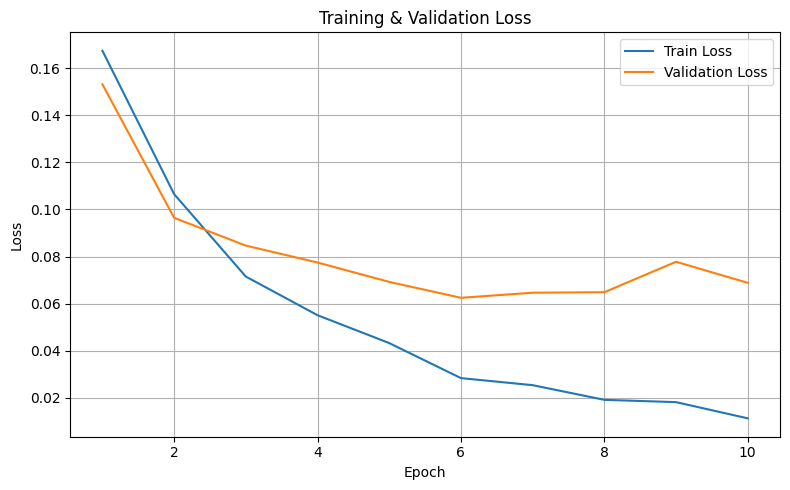

In [10]:
#@title Training the model

import matplotlib.pyplot as plt

num_epochs = 10  # or whatever you’re using
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_gen):
        images = images.view(-1, 28*28).cuda()
        labels = labels.cuda()

        optimizer.zero_grad()
        outputs = net(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if (i+1) % 100 == 0:
            avg_train = running_loss / 100
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}], Avg Train Loss: {avg_train:.4f}')
            running_loss = 0.0

    # save last avg_train of epoch (or adjust to your preferred frequency)
    train_losses.append(avg_train)

    # ——— Validation pass ———
    net.eval()
    val_loss = 0.0
    val_steps = 0
    with torch.no_grad():
        for images, labels in test_gen:
            images = images.view(-1, 28*28).cuda()
            labels = labels.cuda()
            outputs = net(images)
            loss = loss_function(outputs, labels)
            val_loss += loss.item()
            val_steps += 1

    avg_val = val_loss / val_steps
    val_losses.append(avg_val)
    print(f'*** Epoch [{epoch+1}/{num_epochs}] Validation Loss: {avg_val:.4f} ***')

# ——— Plotting ———
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, color='tab:blue',  label='Train Loss')
plt.plot(epochs, val_losses,   color='tab:orange', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [11]:
#@title Evaluating the accuracy of the model

correct = 0
total = 0
for images,labels in test_gen:
  images = Variable(images.view(-1,28*28)).cuda()
  labels = labels.cuda()

  output = net(images)
  _, predicted = torch.max(output,1)
  correct += (predicted == labels).sum()
  total += labels.size(0)

print('Accuracy of the model: %.3f %%' %((100*correct)/(total+1)))

Accuracy of the model: 98.030 %
